# Decision Trees — From Intuition to Code

So far, we've learned:
- **Linear Regression**: Predict a continuous number using a straight line.
- **Logistic Regression**: Predict a binary category by drawing a straight decision boundary using Gradient Descent.
- **Naive Bayes**: Predict a category by combining probabilities — no Gradient Descent, just statistics.

Now, we're going to learn a model that works in a completely different way. Instead of drawing lines or calculating bell curves, it plays a game of **"20 Questions"** with your data.

Welcome to **Decision Trees**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


---
## 1. The Intuition: Playing "20 Questions"

Imagine you're trying to decide whether to play cricket outside. You'd ask yourself a series of questions:

1. **Is it raining?**
   - Yes → **Don't play!** (Stop here.)
   - No → Ask another question:
2. **Is the temperature above 40°C?**
   - Yes → **Don't play!** (Too hot.)
   - No → Ask another question:
3. **Is it windy?**
   - Yes → **Don't play!**
   - No → **Play!**

That's it. That's a Decision Tree. It's a **flowchart of Yes/No questions** that leads you to a final answer.

A Decision Tree algorithm does the **exact same thing**, except:
- It **automatically figures out** which questions to ask (which features to split on).
- It **automatically figures out** the best thresholds (e.g., "Is temperature > 40?" vs. "Is temperature > 35?").
- It optimizes the **order** of questions so that the most useful question is asked first.

---
## 2. Anatomy of a Decision Tree

Every decision tree has three types of components:

| Component | Description | Analogy |
|---|---|---|
| **Root Node** | The very first question at the top of the tree | The first and most important question |
| **Decision Nodes** (Internal Nodes) | Questions in the middle that split the data further | Follow-up questions |
| **Leaf Nodes** | The final answers at the bottom — no more questions | The prediction (Class 0 or Class 1) |
| **Branches** | The arrows connecting nodes — represent Yes or No | The path you take based on the answer |

```
            [Is it raining?]         ← Root Node
           /               \\
         Yes                No
         /                   \\
   [Don't Play]      [Temperature > 40?]  ← Decision Node
    (Leaf)            /              \\
                    Yes              No
                    /                 \\
             [Don't Play]          [Play!]  ← Leaf Nodes
```

---
## 3. The Big Question: How Does the Tree Decide Which Question to Ask?

This is the core of the algorithm. The tree needs to figure out:
1. **Which feature** to split on (e.g., "Rain" vs. "Temperature" vs. "Wind")
2. **What threshold** to use (e.g., "Temperature > 35" vs. "Temperature > 40")

The answer: It picks the question that **best separates** the classes. After the split, each group should ideally be as **pure** as possible — meaning all items in a group belong to the same class.

But how do we **measure** purity? That's where **Gini Impurity** and **Entropy** come in.

Think of it like this: If you have a bag of balls and they're ALL red, the bag is perfectly **pure**. If the bag is 50% red and 50% blue, it's maximally **impure** (you can't predict the next ball's color).

The tree tries every possible split, measures the resulting purity, and picks the one that creates the **purest** groups.

---
## 4. Gini Impurity

Gini Impurity measures how often a randomly chosen element would be **incorrectly classified** if it were randomly labeled according to the distribution of labels in the subset.

$$\text{Gini}(S) = 1 - \sum_{i=1}^{C} p_i^2$$

Where $p_i$ is the proportion of class $i$ in the set $S$, and $C$ is the number of classes.

For a binary classification problem (2 classes):

$$\text{Gini}(S) = 1 - p_1^2 - p_2^2$$

Let's see what Gini values look like:

| Distribution | Gini | Meaning |
|---|---|---|
| 100% Class A, 0% Class B | $1 - 1^2 - 0^2 = 0.0$ | **Perfectly pure** — best possible! |
| 80% Class A, 20% Class B | $1 - 0.8^2 - 0.2^2 = 0.32$ | Mostly pure |
| 50% Class A, 50% Class B | $1 - 0.5^2 - 0.5^2 = 0.5$ | **Maximum impurity** — worst possible! |

**Goal: Find the split that minimizes the Gini Impurity of the resulting child nodes.**

In [4]:
def gini_impurity(y):
    """Calculate Gini Impurity for a set of labels."""
    if len(y) == 0:
        return 0
    counts = np.bincount(y)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)


print(f"All Class 0:      Gini = {gini_impurity(np.array([0,0,0,0,0])):.4f}  (pure!)")
print(f"80/20 split:      Gini = {gini_impurity(np.array([0,0,0,0,1])):.4f}")
print(f"50/50 split:      Gini = {gini_impurity(np.array([0,0,1,1])):.4f}  (max impurity!)")
print(f"All Class 1:      Gini = {gini_impurity(np.array([1,1,1,1,1])):.4f}  (pure!)")

All Class 0:      Gini = 0.0000  (pure!)
80/20 split:      Gini = 0.3200
50/50 split:      Gini = 0.5000  (max impurity!)
All Class 1:      Gini = 0.0000  (pure!)


---
## 5. Entropy & Information Gain

**Entropy** is an alternative measure of impurity from Information Theory. It measures the **disorder** or **uncertainty** in a set of labels:

$$\text{Entropy}(S) = -\sum_{i=1}^{C} p_i \cdot \log_2(p_i)$$

| Distribution | Entropy | Meaning |
|---|---|---|
| 100% Class A, 0% Class B | $0.0$ | **Perfectly pure** — zero uncertainty |
| 80% Class A, 20% Class B | $0.72$ | Low uncertainty |
| 50% Class A, 50% Class B | $1.0$ | **Maximum uncertainty** — a coin flip! |

**Information Gain** is the **reduction in entropy** after a split:

$$\text{InfoGain} = \text{Entropy}_{\text{parent}} - \sum \frac{|S_{\text{child}}|}{|S_{\text{parent}}|} \cdot \text{Entropy}_{\text{child}}$$

The tree picks the split that gives the **highest Information Gain** (or equivalently, the **lowest weighted child entropy**).

In [6]:
def entropy(y):
    """Calculate Entropy for a set of labels."""
    if len(y) == 0:
        return 0
    counts = np.bincount(y)
    probabilities = counts / len(y)

    # Filter out zeros to avoid log(0)
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

print(f"All Class 0:      Entropy = {entropy(np.array([0,0,0,0,0])):.4f}  (pure!)")
print(f"80/20 split:      Entropy = {entropy(np.array([0,0,0,0,1])):.4f}")
print(f"50/50 split:      Entropy = {entropy(np.array([0,0,1,1])):.4f}  (max uncertainty!)")
print(f"All Class 1:      Entropy = {entropy(np.array([1,1,1,1,1])):.4f}  (pure!)")

All Class 0:      Entropy = -0.0000  (pure!)
80/20 split:      Entropy = 0.7219
50/50 split:      Entropy = 1.0000  (max uncertainty!)
All Class 1:      Entropy = -0.0000  (pure!)


---
## 6. Gini vs Entropy — Which to Use?

Let's visualize them side by side.

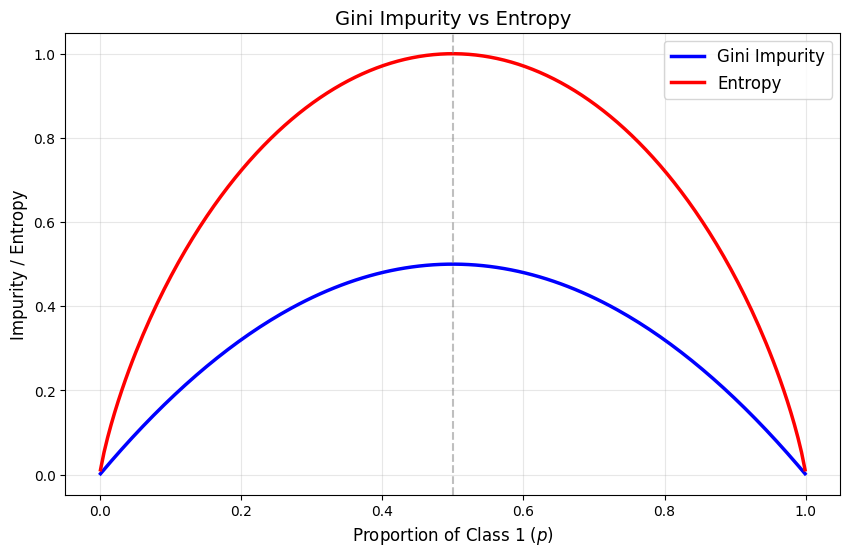

In [8]:
# Visualize Gini vs Entropy for binary classification
p = np.linspace(0.001, 0.999, 200)

gini_values = 1 - p**2 - (1-p)**2
entropy_values = -p * np.log2(p) - (1-p) * np.log2(1-p)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p, gini_values, color='blue', linewidth=2.5, label='Gini Impurity')
ax.plot(p, entropy_values, color='red', linewidth=2.5, label='Entropy')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Proportion of Class 1 ($p$)', fontsize=12)
ax.set_ylabel('Impurity / Entropy', fontsize=12)
ax.set_title('Gini Impurity vs Entropy', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

Both curves have the **same shape** — they peak at 50/50 and reach zero at the extremes. In practice, they give very similar results. Scikit-Learn uses **Gini by default** because it's slightly faster to compute (no logarithm needed).

| Criterion | Formula | Range | Default In |
|---|---|---|---|
| **Gini Impurity** | $1 - \sum p_i^2$ | 0 to 0.5 | Scikit-Learn |
| **Entropy** | $-\sum p_i \log_2 p_i$ | 0 to 1.0 | Academic/Textbooks |

---
## 7. Step-by-Step: How the Tree Grows

Let's walk through a tiny example by hand to see the algorithm in action.

In [9]:
# Tiny weather dataset
data = {
    'Temperature': [30, 35, 40, 25, 38, 42, 28, 33],
    'Humidity':    [80, 70, 90, 65, 85, 95, 60, 75],
    'Play':        [1,  1,  0,  1,  0,  0,  1,  1]   # 1 = Play, 0 = Don't Play
}
df = pd.DataFrame(data)
display(df)

,Temperature,Humidity,Play
0,30,80,1
1,35,70,1
2,40,90,0
3,25,65,1
4,38,85,0
5,42,95,0
6,28,60,1
7,33,75,1


In [11]:
# What's the Gini of the whole dataset BEFORE any split?
parent_gini = gini_impurity(df['Play'].values)
print(f"Parent Gini (before split): {parent_gini:.4f}")
print(f"  → Distribution: {sum(df['Play']==1)} Play, {sum(df['Play']==0)} Don't Play")
print()

# Let's try splitting on Temperature <= 35
left = df[df['Temperature'] <= 35]['Play'].values   # Left child (Temp <= 35)
right = df[df['Temperature'] > 35]['Play'].values    # Right child (Temp > 35)

gini_left = gini_impurity(left)
gini_right = gini_impurity(right)

# Weighted average Gini of the children
n = len(df)
weighted_gini = (len(left)/n) * gini_left + (len(right)/n) * gini_right

print(f"Split: Temperature <= 35")
print(f"  Left  (Temp <= 35): {left} → Gini = {gini_left:.4f}")
print(f"  Right (Temp > 35):  {right} → Gini = {gini_right:.4f}")
print(f"  Weighted Gini after split: {weighted_gini:.4f}")
print(f"  Gini Reduction: {parent_gini - weighted_gini:.4f}")

Parent Gini (before split): 0.4688
  → Distribution: 5 Play, 3 Don't Play

Split: Temperature <= 35
  Left  (Temp <= 35): [1 1 1 1 1] → Gini = 0.0000
  Right (Temp > 35):  [0 0 0] → Gini = 0.0000
  Weighted Gini after split: 0.0000
  Gini Reduction: 0.4688


In [12]:
# Now let's try ALL possible splits and find the best one!
best_gini = float('inf')
best_feature = None
best_threshold = None

for feature in ['Temperature', 'Humidity']:
    values = sorted(df[feature].unique())
    # Try thresholds between consecutive unique values
    for i in range(len(values) - 1):
        threshold = (values[i] + values[i+1]) / 2
        left = df[df[feature] <= threshold]['Play'].values
        right = df[df[feature] > threshold]['Play'].values
        
        wg = (len(left)/n) * gini_impurity(left) + (len(right)/n) * gini_impurity(right)
        
        if wg < best_gini:
            best_gini = wg
            best_feature = feature
            best_threshold = threshold

print(f"Best split found!")
print(f"  Feature:   {best_feature}")
print(f"  Threshold: {best_threshold}")
print(f"  Weighted Gini: {best_gini:.4f}")
print(f"  Gini Reduction: {parent_gini - best_gini:.4f}")

Best split found!
  Feature:   Temperature
  Threshold: 36.5
  Weighted Gini: 0.0000
  Gini Reduction: 0.4688


That's the **greedy algorithm** at the heart of every Decision Tree:
1. Try **every feature** and **every possible threshold**.
2. Pick the (feature, threshold) combo that produces the **lowest weighted Gini** (or highest Information Gain).
3. Split the data into two groups.
4. **Repeat recursively** on each group until a stopping condition is met.

---
## 8. When and Why to Use Decision Trees

### Use Decision Trees when:
- You need a model that is **easy to explain** and **visualize** (business stakeholders love trees!)
- Your data has **non-linear relationships** (trees can capture complex patterns that a straight line can't)
- You have a **mix of numerical and categorical features** — trees handle both naturally
- **Feature scaling is not needed** — unlike Logistic Regression and NB, trees don't care about the magnitude of values
- You want a **quick, interpretable baseline** before trying more complex models

### Avoid Decision Trees when:
- **Accuracy is critical** — a single tree is often outperformed by ensemble methods (Random Forest, XGBoost)
- Your data is very **high-dimensional** (thousands of features like text data) — NB is faster here
- The **decision boundary is truly linear** — Logistic Regression will be simpler and better

### Decision Trees vs. Other Models

| Aspect | Decision Tree | Logistic Regression | Naive Bayes |
|---|---|---|---|
| **Decision Boundary** | Non-linear (axis-aligned rectangles) | Linear (straight line) | Non-linear (curved) |
| **Interpretability** | Very high — you can visualize the tree! | Moderate | Low |
| **Feature Scaling** | Not needed | Required | Not needed |
| **Handles Categorical** | Yes, naturally | Needs encoding | Yes (Multinomial NB) |
| **Overfitting Risk** | Very high | Low | Very low |
| **Training Speed** | Fast | Moderate (Gradient Descent) | Very fast |
| **Best For** | Tabular data, explainability | Linear relationships | Text, small datasets |

---
## 9. The Biggest Weakness: Overfitting

A Decision Tree's biggest enemy is **overfitting**. If you let the tree grow without any limits, it will keep splitting until every single leaf node is perfectly pure — even if it means creating a rule like *"If Temperature is 33.7 AND Humidity is 74.2 → Play"*.

This gives you 100% accuracy on the **training** data but terrible accuracy on **new, unseen** data. The tree has memorized the training data instead of learning general patterns.

### How to Fight Overfitting (Hyperparameters)

| Hyperparameter | What it Does | Effect |
|---|---|---|
| `max_depth` | Limit how many levels deep the tree can grow | Prevents the tree from getting too complex |
| `min_samples_split` | Minimum samples required to split a node | Stops splitting when groups are too small |
| `min_samples_leaf` | Minimum samples required in a leaf node | Ensures each final answer has enough evidence |
| `max_features` | Limit how many features to consider per split | Adds randomness, reduces overfitting |

### Pruning
Another approach is **pruning** — growing a full tree first, then removing branches that don't improve performance on a validation set. This is like editing an essay after writing it: remove the parts that don't add value.

---
## 10. About "Loss Functions" in Decision Trees

Like Naive Bayes, Decision Trees **don't optimize a traditional loss function** using Gradient Descent.

Instead, they use a **greedy, recursive splitting strategy**:
- At each node, the tree evaluates every possible split.
- It picks the one that gives the best **Gini Impurity** (or **Entropy**) improvement.
- This is a **local** optimization — it doesn't look ahead to see if a different split now would lead to a better tree later.

The "loss" is implicitly the **impurity measure** (Gini or Entropy) at each step. But unlike Logistic Regression, there's no single global loss function being minimized over epochs. The tree is built top-down in a single pass.

For **evaluation** after training, we still use standard classification metrics:
- **Accuracy**, **Precision**, **Recall**, **F1-Score**
- **Confusion Matrix**
- **Log Loss** (if using probability predictions)

> **For Regression Trees** (predicting numbers, not categories), the splitting criterion is **Mean Squared Error (MSE)** instead of Gini/Entropy. The tree picks the split that minimizes MSE in the resulting child nodes.

---
## 11. Building a Decision Tree from Scratch

In [25]:
class TreeNode:
    """A single node in our decision tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature        # Index of the feature to split on
        self.threshold = threshold    # Threshold value to split at
        self.left = left              # Left child (feature <= threshold)
        self.right = right            # Right child (feature > threshold)
        self.value = value            # Predicted class (only for leaf nodes)

    def is_leaf(self):
        return self.value is not None

class MyDecisionTree:
    def __init__(self, max_depth=10, min_samples_split=2, criterion='gini'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.criterion = criterion
        self.root = None

    def _impurity(self, y):
        """Calculate impurity using the chosen criterion."""
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / len(y)
        if self.criterion == 'gini':
            return 1 - np.sum(probs ** 2)
        else:  # entropy
            probs = probs[probs > 0]
            return -np.sum(probs * np.log2(probs))

    def _best_split(self, X, y):
        """Find the best feature and threshold to split on."""
        best_gain = -1
        best_feature = None
        best_threshold = None

        parent_impurity = self._impurity(y)
        n = len(y)

        for feature_idx in range(X.shape[1]):
            # Get the sorted unique values for this feature
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                # Split the data
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                # Calculate weighted impurity of children
                left_impurity = self._impurity(y[left_mask])
                right_impurity = self._impurity(y[right_mask])
                weighted = (np.sum(left_mask)/n) * left_impurity + (np.sum(right_mask)/n) * right_impurity

                # Information Gain = Parent Impurity - Weighted Child Impurity
                gain = parent_impurity - weighted

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth=0):
        """Recursively build the decision tree."""
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # --- STOPPING CONDITIONS ---
        # 1. Max depth reached
        # 2. Node is perfectly pure (only 1 class)
        # 3. Not enough samples to split
        if depth >= self.max_depth or n_classes == 1 or n_samples < self.min_samples_split:
            # Make this a leaf node — predict the majority class
            leaf_value = np.bincount(y).argmax()
            return TreeNode(value=leaf_value)

        # Find the best split
        best_feature, best_threshold, best_gain = self._best_split(X, y)

        # If no good split was found, make this a leaf
        if best_gain <= 0:
            leaf_value = np.bincount(y).argmax()
            return TreeNode(value=leaf_value)

        # Split the data and recurse
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return TreeNode(feature=best_feature, threshold=best_threshold,
                        left=left_child, right=right_child)

    def fit(self, X, y):
        """Train the decision tree."""
        if isinstance(X, pd.DataFrame):
            X = X.values
        self.root = self._build_tree(X, y)
        return self

    def _predict_single(self, x, node):
        """Traverse the tree to make a prediction for a single sample."""
        if node.is_leaf():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._predict_single(x, node.left)
        else:
            return self._predict_single(x, node.right)

    def predict(self, X):
        """Predict classes for multiple samples."""
        if isinstance(X, pd.DataFrame):
            X = X.values
        return np.array([self._predict_single(x, self.root) for x in X])

    def _print_tree(self, node, depth=0, prefix="ROOT"):
        """Print the tree structure for visualization."""
        indent = "    " * depth
        if node.is_leaf():
            print(f"{indent}{prefix} → Predict Class {node.value}")
        else:
            print(f"{indent}{prefix} [Feature {node.feature} <= {node.threshold:.2f}?]")
            self._print_tree(node.left, depth + 1, "Yes")
            self._print_tree(node.right, depth + 1, "No ")

    def print_tree(self):
        self._print_tree(self.root)

print("MyDecisionTree class defined!")

MyDecisionTree class defined!


### Key Design Decisions:

1. **`TreeNode` class**: Each node stores either a (feature, threshold) for decision nodes, or a `value` (predicted class) for leaf nodes.

2. **`_best_split()`**: The brute-force heart of the algorithm — it tries every feature and every unique value as a threshold, picks the one with the best impurity reduction.

3. **`_build_tree()`**: Recursive function that builds the tree top-down. It stops when:
   - Max depth is reached (prevents overfitting)
   - The node is already pure (only one class left)
   - Not enough samples to split further

4. **`predict()`**: Walks down the tree for each sample — at each decision node, go left if the feature value is ≤ the threshold, else go right. When you reach a leaf, return the predicted class.

5. **`print_tree()`**: Prints the tree structure so we can actually see what questions it's asking!

---
## 12. Testing on a Real(ish) Dataset

In [26]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate a binary classification dataset with 2 features for visualization
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,  # Makes it non-linear — perfect for trees!
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features:         {X_train.shape[1]}")

Training samples: 400
Testing samples:  100
Features:         2


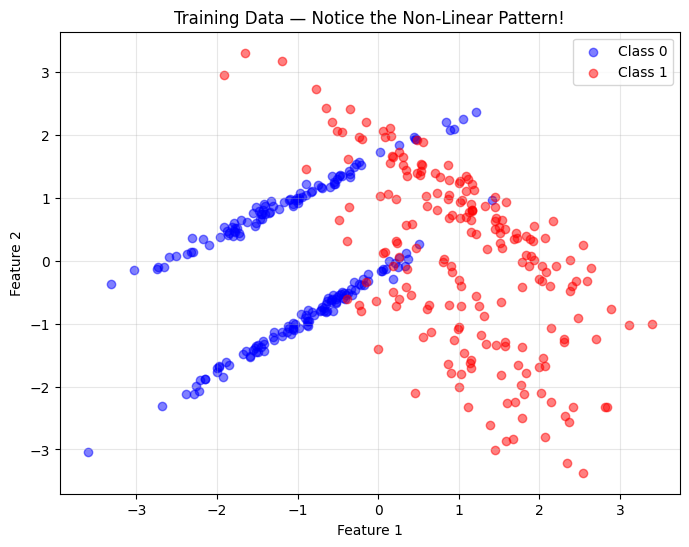

In [27]:
# Visualize the training data
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='blue', alpha=0.5, label='Class 0')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', alpha=0.5, label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training Data — Notice the Non-Linear Pattern!')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Notice how the two classes are **interleaved** in a complex, non-linear pattern. A straight line (Logistic Regression) would struggle here, but a Decision Tree can carve out rectangular regions to separate them!

---
## 13. Train and Visualize the Tree

In [28]:
# Train our custom tree (limit depth to keep it readable)
my_tree = MyDecisionTree(max_depth=4, criterion='gini')
my_tree.fit(X_train, y_train)

print("=" * 60)
print("         OUR DECISION TREE STRUCTURE")
print("=" * 60)
my_tree.print_tree()

         OUR DECISION TREE STRUCTURE
ROOT [Feature 0 <= -0.21?]
    Yes [Feature 1 <= 1.57?]
        Yes [Feature 0 <= -0.40?]
            Yes [Feature 1 <= 1.36?]
                Yes → Predict Class 0
                No  → Predict Class 1
            No  [Feature 0 <= -0.37?]
                Yes → Predict Class 1
                No  → Predict Class 0
        No  → Predict Class 1
    No  [Feature 0 <= 0.51?]
        Yes [Feature 1 <= 0.12?]
            Yes [Feature 1 <= -0.42?]
                Yes → Predict Class 1
                No  → Predict Class 0
            No  [Feature 0 <= 0.42?]
                Yes → Predict Class 1
                No  → Predict Class 0
        No  [Feature 1 <= 1.90?]
            Yes [Feature 1 <= 0.97?]
                Yes → Predict Class 1
                No  → Predict Class 1
            No  → Predict Class 0


You can literally read the tree like a flowchart! Each line is a question, and the indentation shows which questions follow from which answers.

---
## 14. Evaluate: Custom Model vs. Scikit-Learn

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# --- Our Custom Model ---
my_preds = my_tree.predict(X_test)
my_accuracy = accuracy_score(y_test, my_preds)

# --- Scikit-Learn's Model (same hyperparameters) ---
sk_tree = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
sk_tree.fit(X_train, y_train)
sk_preds = sk_tree.predict(X_test)
sk_accuracy = accuracy_score(y_test, sk_preds)

print("=" * 50)
print("           MODEL COMPARISON")
print("=" * 50)
print(f"{'':15} {'MyDecisionTree':>14} {'Sklearn DT':>14}")
print("-" * 50)
print(f"{'Accuracy':15} {my_accuracy:>13.2%} {sk_accuracy:>13.2%}")
print("=" * 50)

           MODEL COMPARISON
                MyDecisionTree     Sklearn DT
--------------------------------------------------
Accuracy               89.00%        89.00%


---
## 15. Visualize the Decision Boundary

This is the most revealing visualization. Unlike Logistic Regression (which draws a straight line) or Naive Bayes (which draws curves), a Decision Tree creates **rectangular regions** — because every split is a horizontal or vertical cut along a single feature axis.

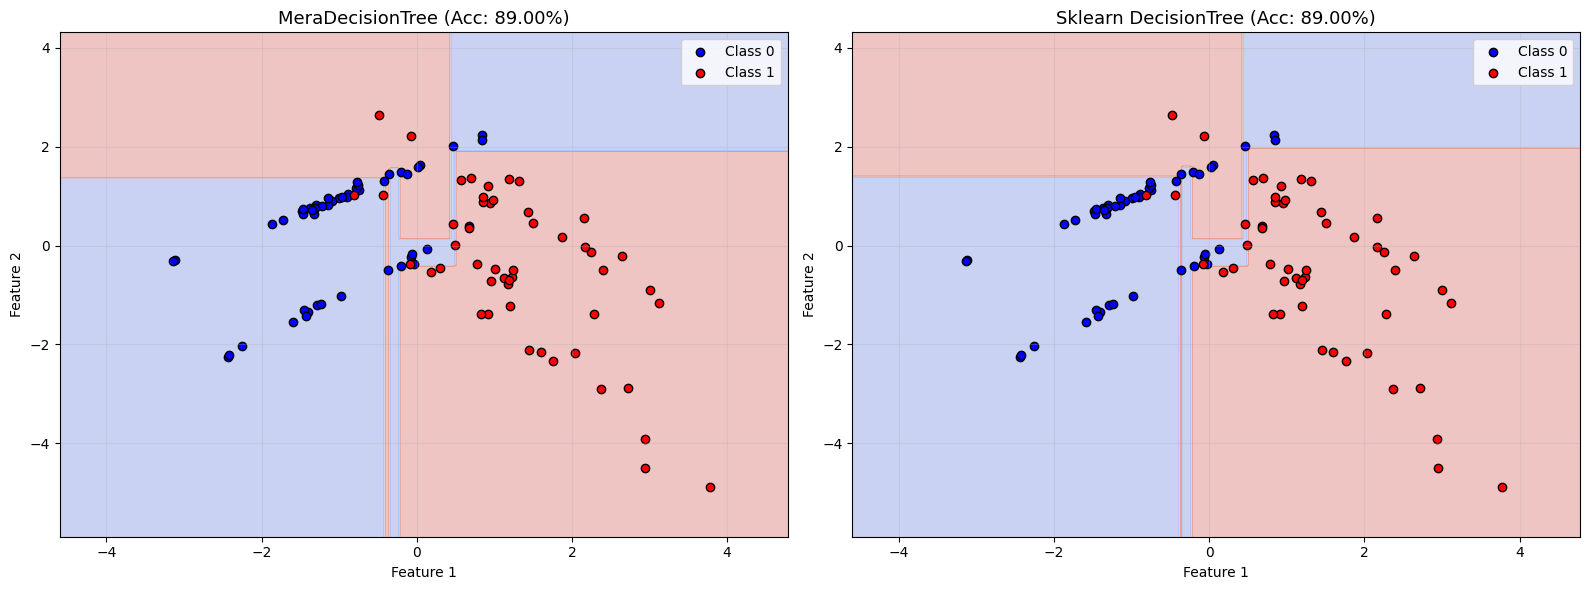

In [30]:
# Create a mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

# Predict every point on the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_preds = my_tree.predict(grid_points).reshape(xx.shape)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Our Custom Tree
axes[0].contourf(xx, yy, grid_preds, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='blue', edgecolors='k', label='Class 0')
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='red', edgecolors='k', label='Class 1')
axes[0].set_title(f'MeraDecisionTree (Acc: {my_accuracy:.2%})', fontsize=13)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Sklearn's Tree
grid_preds_sk = sk_tree.predict(grid_points).reshape(xx.shape)
axes[1].contourf(xx, yy, grid_preds_sk, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='blue', edgecolors='k', label='Class 0')
axes[1].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='red', edgecolors='k', label='Class 1')
axes[1].set_title(f'Sklearn DecisionTree (Acc: {sk_accuracy:.2%})', fontsize=13)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Notice the **rectangular, axis-aligned** decision boundaries! Each split creates a horizontal or vertical line, because the tree only asks *"Is Feature X ≤ some value?"* — it never combines features.

---
## 16. Overfitting in Action

Let's demonstrate why `max_depth` is so important. We'll train trees with different depths and watch the accuracy gap between training and testing.

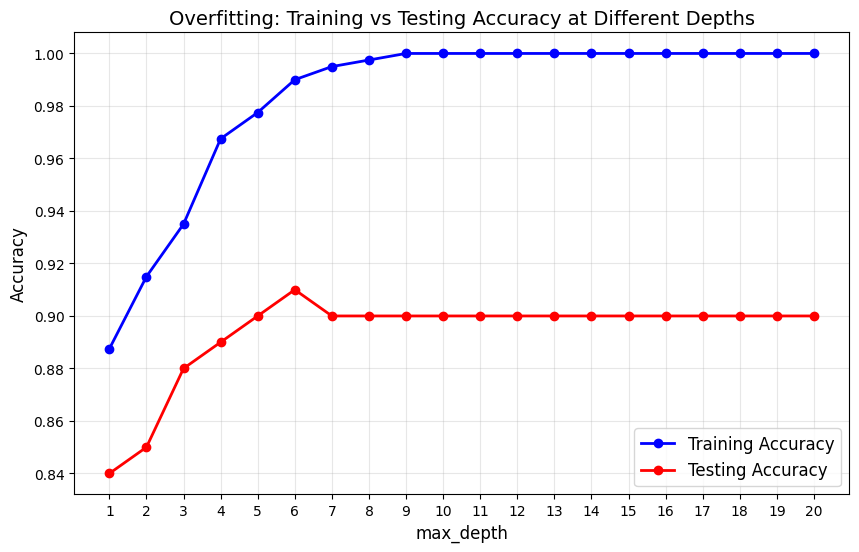

Best test accuracy: 91.00% at max_depth=6


In [31]:
train_accs = []
test_accs = []
depths = range(1, 21)

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_accs, 'o-', color='blue', linewidth=2, label='Training Accuracy')
plt.plot(depths, test_accs, 'o-', color='red', linewidth=2, label='Testing Accuracy')
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Overfitting: Training vs Testing Accuracy at Different Depths', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.show()

best_depth = depths[np.argmax(test_accs)]
print(f"Best test accuracy: {max(test_accs):.2%} at max_depth={best_depth}")

The classic overfitting pattern:
- **Training accuracy** keeps climbing toward 100% as the tree gets deeper.
- **Testing accuracy** improves at first, then **plateaus or drops** once the tree starts memorizing instead of learning.

The best depth is usually somewhere in the middle — complex enough to capture real patterns, but simple enough to generalize to new data.

---
## 17. Bonus: Visualizing Sklearn's Tree with `plot_tree`

One of the best things about Decision Trees is that you can literally **see** the model!

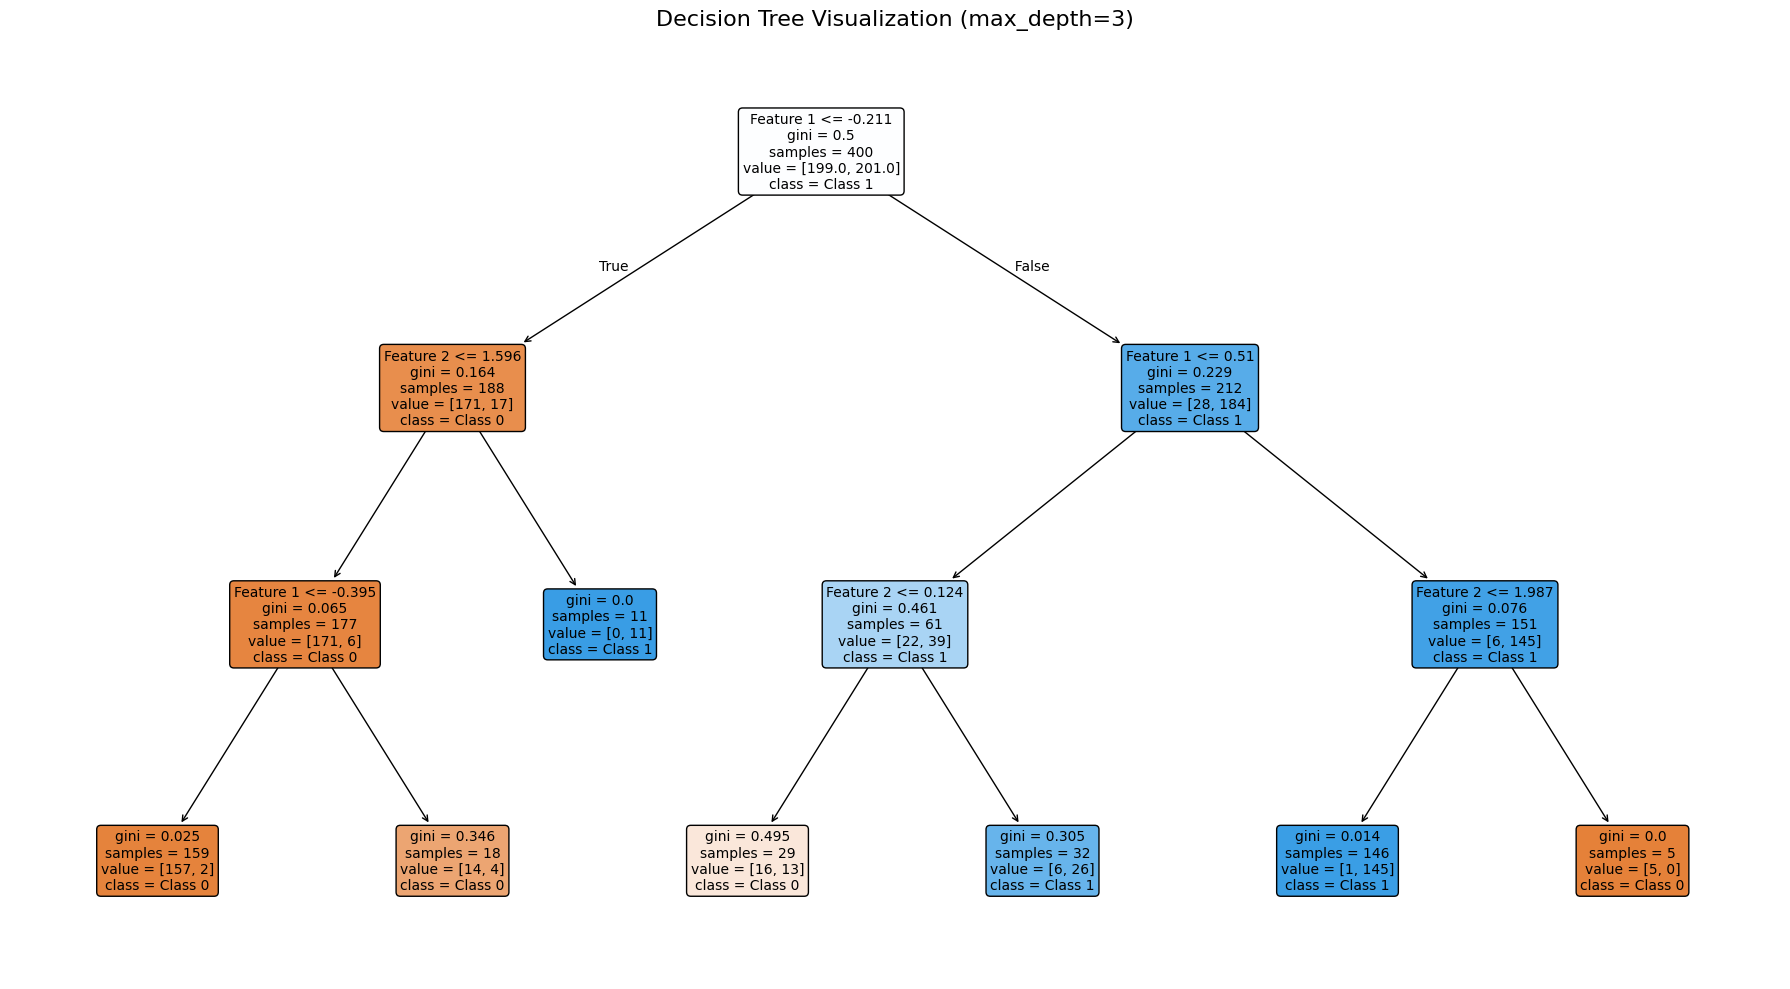

In [32]:
from sklearn.tree import plot_tree

# Train a shallow tree for a clean visualization
viz_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
viz_tree.fit(X_train, y_train)

plt.figure(figsize=(18, 10))
plot_tree(viz_tree,
          feature_names=['Feature 1', 'Feature 2'],
          class_names=['Class 0', 'Class 1'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization (max_depth=3)', fontsize=16)
plt.tight_layout()
plt.show()

Each box shows:
- The **question** being asked (e.g., "Feature 1 <= 0.53")
- The **Gini Impurity** of that node
- The **number of samples** in that node
- The **class distribution** (e.g., [120, 80])
- The **predicted class** (the darker the color, the purer the node)

Try explaining this to a business stakeholder vs. explaining Logistic Regression's weights — the tree is much more intuitive!

---
## 18. Summary

| Concept | Detail |
|---|---|
| **Core Idea** | Ask a series of Yes/No questions to narrow down the prediction |
| **Splitting Criteria** | **Gini Impurity** (default) or **Entropy/Information Gain** |
| **Training** | Greedy, top-down recursive splitting — no Gradient Descent, no epochs |
| **Decision Boundary** | Axis-aligned rectangles (horizontal and vertical cuts) |
| **Biggest Strength** | Highly interpretable — you can visualize and explain the entire model |
| **Biggest Weakness** | **Overfitting** — will memorize data if not constrained |
| **Key Hyperparameters** | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| **Feature Scaling** | Not needed! |
| **Best For** | Tabular data, explainability, non-linear patterns |
| **Leads To** | Random Forest (many trees), Gradient Boosting (XGBoost, LightGBM) |